In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lukechugh_best_alzheimer_mri_dataset_99_accuracy_path = kagglehub.dataset_download('lukechugh/best-alzheimer-mri-dataset-99-accuracy')

print('Data source import complete.')


Using Colab cache for faster access to the 'best-alzheimer-mri-dataset-99-accuracy' dataset.
Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2154).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2263).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2411).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (1094).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (1765).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (647).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (133).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset

DATASET
```
combined dataset
    |__ test
        |__ No Impairment
        |__ Very Mild Impairment
        |__ Moderate Impairment
        |__ Mild Impairment
    |__ train
        |__ No Impairment
        |__ Very Mild Impairment
        |__ Moderate Impairment
        |__ Mild Impairment
```

In [ ]:
import os

In [ ]:
train_data = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train"
test_data = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"

def countImages(path):
    # print(os.listdir(path))
    for i in os.listdir(path):
        # print(i)
        filename = os.path.join(path, i)
        # print(filename)
        # print(os.listdir(filename))
        count = len([img for img in os.listdir(filename) if(img.lower().endswith(('.jpg', '.png', '.jpeg')))])
        print(f"{i} = {count} images")


print("Train")
countImages(train_data)
print("Test")
countImages(test_data)

Train
No Impairment = 2560 images
Very Mild Impairment = 2560 images
Moderate Impairment = 2560 images
Mild Impairment = 2560 images
Test
No Impairment = 640 images
Very Mild Impairment = 448 images
Moderate Impairment = 12 images
Mild Impairment = 179 images


## imbalanced dataset for testing

In [ ]:
mainDir = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
category = ['Mild Impairment', 'Moderate Impairment', "No Impairment", "Very Mild Impairment"]

imagepath = []
label = []

for cat in category:
    for split in ['train', 'test']:
        filepath = os.path.join(mainDir, split, cat)
        for img in os.listdir(filepath):
            img_path = os.path.join(filepath, img)
            imagepath.append(img_path)
            label.append(cat)

data = pd.DataFrame({"image_path" : imagepath, "label": label})


In [ ]:
data.sample(10)

,image_path,label
3562,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
127,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
10461,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Very Mild Impairment
7422,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
4929,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
4813,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
11037,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Very Mild Impairment
2142,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
6964,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
8267,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [ ]:
train_df

,image_path,label
0,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
1,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
2,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
3,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
4,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
...,...,...
9210,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
9211,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
9212,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
9213,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
## Generates images
def show_images(gen):
    classes = list(gen.class_indices.keys())   ## extract labels -- Maps class names → numeric indices
    images, labels = next(gen)         ## extracts batch of images

    num_images = min(len(labels), 16)   ## displays only 16 images

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(images[i])
            label_index = np.argmax(labels[i])
            ax.set_title(classes[label_index])
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f') if normalize else int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
### DATA AUGMENTATION --> generate batches of images on the fly
## rescale=1./255: converts pixel values from [0, 255] → [0, 1] (normalization).
## validation_split=0.2: reserves 20% of training data for validation

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 16
target_size = (224, 224)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=True,
    batch_size=batch_size,
    target_size=target_size,
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=False,
    batch_size=batch_size,
    target_size=target_size,
    subset='validation'
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=False,
    batch_size=batch_size,
    target_size=target_size
)

Found 7372 validated image filenames belonging to 4 classes.
Found 1843 validated image filenames belonging to 4 classes.
Found 2304 validated image filenames belonging to 4 classes.


In [ ]:
print(train_generator.samples)  # total number of images
print(train_generator.batch_size)  # batch size used
print(train_generator.class_indices)  # class names and indices


7372
16
{'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}


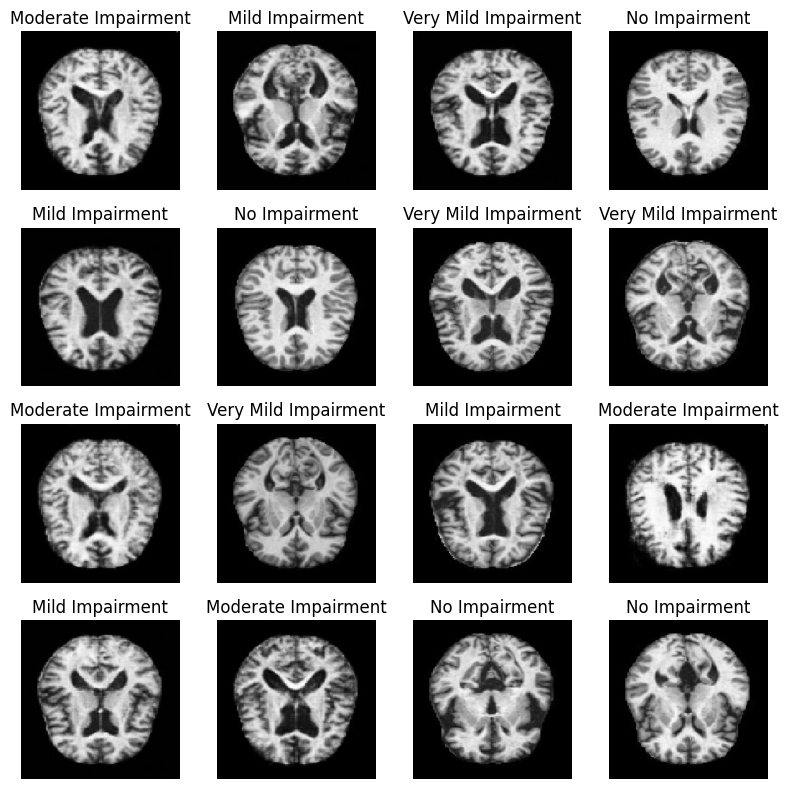

In [ ]:
show_images(train_generator)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

In [ ]:
# # Create Model Structure
# img_size = (224, 224)
# channels = 3
# img_shape = (img_size[0], img_size[1], channels)
# class_count = len(list(train_generator.class_indices.keys())) # defines number of classes in dense layer

# base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max',)

# model = tf.keras.models.Sequential([
#     base_model,
#     Dense(512, activation = 'relu'),
#     Dropout(0.2),
#     Dense(4, activation = 'softmax')
# ])

# model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

# model.summary()

In [ ]:
# model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(), metrics = ['accuracy'])

# early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True, verbose = 1)

# history = model.fit(train_generator,
#     validation_data=test_generator,
#     epochs=50,
#     steps_per_epoch = 100,
#     callbacks = [early_stopping_callbacks])

In [ ]:
# plot_training(history)

In [ ]:
#def plot_history(history):
#   plt.figure(figsize=(14, 5))
#   plt.subplot(1, 2, 1)
#   plt.plot(history.history['accuracy'], label='Train')
#   plt.plot(history.history['val_accuracy'], label='Validation')
#   plt.title('Model Accuracy')
#   plt.ylabel('Accuracy')
#   plt.xlabel('Epoch')
#   plt.legend()
#   plt.subplot(1, 2, 2)
#   plt.plot(history.history['loss'], label='Train')
#   plt.plot(history.history['val_loss'], label='Validation')
#   plt.title('Model Loss')
#   plt.ylabel('Loss')
#   plt.xlabel('Epoch')
#   plt.legend()
#   plt.tight_layout()
#   plt.show()
#plot_history(history)

In [ ]:
# model.summary()

In [ ]:
# preds = model.predict(test_generator, verbose=1)
# y_pred = np.argmax(preds, axis=1)

# # Get class names
# # g_dict = test_generator.class_indices
# classes = list(g_dict.keys())

# # Confusion matrix
# cm = confusion_matrix(test_generator.classes, y_pred)
# plot_confusion_matrix(cm=cm, classes=classes, title='Confusion Matrix')

# # Classification report
# print(classification_report(test_generator.classes, y_pred, target_names=classes))

In [ ]:
'''import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adamax

# Image settings
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Number of classes
class_count = len(list(train_generator.class_indices.keys()))  # e.g., 4

# Load ResNet50 base model
base_model = tf.keras.applications.ResNet50(
    include_top=False,          # remove default classification layer
    weights='imagenet',         # use pretrained ImageNet weights
    input_shape=img_shape,
    pooling='max'               # global max pooling
)

# Build full model
model = Sequential([
    base_model,
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(class_count, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



SyntaxError: incomplete input (ipython-input-401012565.py, line 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model

# Image settings
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Load base model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

# Freeze base model if needed
base_model.trainable = True  # or False if you’re using pretrained as fixed

# Build using Functional API
x = base_model.output
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(class_count, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
print(model.output)


<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_950>


In [ ]:
def overlay_heatmap(img_rgb, heatmap, alpha=0.4, colormap='jet'):
    """
    img_rgb: numpy array HxW x 3 in uint8 or float [0..255] or [0..1]
    heatmap: H x W float [0..1]
    returns: overlayed image HxW x 3 uint8
    """
    import matplotlib.cm as cm
    if img_rgb.dtype != np.uint8:
        # scale to [0,255]
        img_rgb = np.uint8(np.clip(img_rgb, 0, 1) * 255) if np.max(img_rgb) <= 1.0 else np.uint8(np.clip(img_rgb, 0, 255))

    # apply colormap
    cmap = cm.get_cmap(colormap)
    heatmap_colored = cmap(heatmap)[:, :, :3]  # H,W,3 floats [0..1]
    heatmap_colored = np.uint8(heatmap_colored * 255)

    overlay = np.uint8((1.0 - alpha) * img_rgb + alpha * heatmap_colored)
    return overlay


In [ ]:
# model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(), metrics = ['accuracy'])

early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True, verbose = 1)

history = model.fit(train_generator,
    validation_data=test_generator,
    epochs=30,
    steps_per_epoch = 50,
    callbacks = [early_stopping_callbacks])

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 401ms/step - accuracy: 0.4562 - loss: 13.6939 - val_accuracy: 0.2231 - val_loss: 625.1299
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 311ms/step - accuracy: 0.5751 - loss: 2.2879 - val_accuracy: 0.2778 - val_loss: 1.4313
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - accuracy: 0.6147 - loss: 2.0314 - val_accuracy: 0.2378 - val_loss: 1.3891
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 690ms/step - accuracy: 0.6826 - loss: 0.7576 - val_accuracy: 0.2378 - val_loss: 1.3911
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - accuracy: 0.6751 - loss: 0.9459 - val_accuracy: 0.2378 - val_loss: 1.3931
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 312ms/step - accuracy: 0.7432 - loss: 0.7585 - val_accuracy: 0.2378 - val_loss: 1.3898
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 312ms/step - accuracy: 0.7137 - loss: 0.7021 - val_accuracy: 0.2539 - val_loss: 1.3850
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.7575 - loss: 0.8484 - val_accuracy: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.7911 - loss: 1.2518 - val_accuracy: 0.2231 - val_loss: 1.3301
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 303ms/step - accuracy: 0.8153 - loss: 0.4898 - val_accuracy: 0.2231 - val_loss: 1.3194
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 309ms/step - accuracy: 0.7648 - loss: 0.8111 - val_accuracy: 0.2287 - val_loss: 1.2964
Epoch 13/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - accuracy: 0.7915 - loss: 0.5180 - val_accuracy: 0.3286 - val_loss: 1.2502
Epoch 14/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 306ms/step - accuracy: 0.8517 - loss: 0.3470 - val_accuracy: 0.4084 - val_loss: 1.1914
Epoch 15/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.8547 - loss: 0.4310 - val_accuracy: 0.4245 - val_loss: 1.1972
Epoch 16/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 304ms/step - accuracy: 0.8692 - loss: 0.3512 - val_accuracy: 0.4575 - val_loss: 1.3447
Epoch 17/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 305ms/step - accuracy: 0.8900 - loss: 0.2874 - val_accuracy:

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def display_scorecam(model, img_path, last_conv_layer_name="conv5_block3_out", img_size=(224,224), class_labels=None):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    # Make prediction
    preds = model.predict(img_array)
    class_index = np.argmax(preds[0])
    class_prob = preds[0][class_index]

    # Create a model that outputs conv feature maps and predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    conv_outputs, predictions = grad_model(img_array)
    conv_outputs = conv_outputs[0].numpy()

    # Generate Score-CAM
    weights = []
    for i in range(conv_outputs.shape[-1]):
        cam = conv_outputs[..., i]
        cam = np.maximum(cam, 0)
        cam = cam / (np.max(cam) + 1e-8)
        cam_resized = cv2.resize(cam, img_size)
        score = model.predict(np.expand_dims(img_array[0] * np.expand_dims(cam_resized, axis=-1), axis=0))[0][class_index]
        weights.append(score)
    weights = np.array(weights)

    scorecam = np.dot(conv_outputs, weights)
    heatmap = np.maximum(scorecam, 0)
    heatmap /= np.max(heatmap)
    heatmap = cv2.resize(heatmap, img_size)
    heatmap = np.uint8(255 * heatmap)

    # Overlay heatmap on image
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(np.uint8(img), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

    # Determine title text
    if class_labels:
        pred_label = class_labels[class_index]
        title_text = f"Pred: {pred_label} ({class_index}), Prob: {class_prob:.3f}"
    else:
        title_text = f"Pred: {class_index}, Prob: {class_prob:.3f}"

    # Display
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(title_text)
    plt.axis("off")
    plt.show()


In [ ]:
'''import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model

def display_scorecam(model, img_path, last_conv_layer_name):
    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    # Create a model that maps input to the last conv layer and output
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    # Forward pass
    conv_outputs, predictions = grad_model(img_array)
    conv_outputs = conv_outputs[0]  # shape: (7, 7, 2048)
    pred_index = tf.argmax(predictions[0])
    print(f"Predicted class index: {pred_index}")

    # Normalize conv outputs
    conv_outputs = tf.image.resize(conv_outputs, (224, 224))
    conv_outputs = conv_outputs.numpy()

    # Initialize the score map
    score_cam = np.zeros((224, 224), dtype=np.float32)

    for i in range(conv_outputs.shape[-1]):
        # Get feature map and normalize
        fmap = conv_outputs[..., i]
        fmap = (fmap - np.min(fmap)) / (np.max(fmap) - np.min(fmap) + 1e-8)
        fmap = np.expand_dims(fmap, axis=(0, -1))

        # Apply the feature map as mask and forward through the model
        masked_input = img_array * fmap
        score = model(masked_input)[0][pred_index]
        score_cam += score * conv_outputs[..., i]

    # Normalize heatmap
    score_cam = np.maximum(score_cam, 0)
    score_cam = score_cam / (np.max(score_cam) + 1e-8)

    # Convert heatmap to RGB
    heatmap = cv2.applyColorMap(np.uint8(255 * score_cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on the original image
    img_display = np.uint8(255 * (img_array[0] - np.min(img_array[0])) / (np.max(img_array[0]) - np.min(img_array[0])))
    overlay = cv2.addWeighted(img_display, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Score-CAM Visualization")
    plt.show()


In [ ]:
'''import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def gradcam_plus_plus(model, img_array, last_conv_layer_name, class_index=3):
    # Get the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Create model to map input to conv outputs + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [last_conv_layer.output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape(persistent=True) as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        output = predictions[:, class_index]

        # Compute gradients
        grads = tape.gradient(output, conv_outputs)
        first = tape.gradient(tf.reduce_sum(output), conv_outputs)
        second = tape.gradient(tf.reduce_sum(first), conv_outputs)
        third = tape.gradient(tf.reduce_sum(second), conv_outputs)

    # Convert to numpy arrays
    conv_outputs = conv_outputs[0].numpy()
    grads = grads[0].numpy()
    first = first[0].numpy()
    second = second[0].numpy()
    third = third[0].numpy()

    # Compute alpha weights (Grad-CAM++)
    numerator = second
    denominator = 2 * second + third * np.sum(conv_outputs * grads, axis=(0, 1))
    denominator = np.where(denominator != 0, denominator, 1e-10)
    alphas = numerator / denominator
    weights = np.maximum(grads, 0) * np.sum(alphas, axis=(0, 1))

    # Compute heatmap
    heatmap = np.sum(weights * conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad


def modify_relu_to_guided(model):
    """Replace all ReLU activations with guided ReLU in the model."""
    for layer in model.layers:
        if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
            layer.activation = guided_relu
    return model

def overlay_heatmap(heatmap, img_path, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    overlayed = cv2.addWeighted(heatmap, alpha, img, 1 - alpha, 0)
    return overlayed


In [ ]:
os.listdir('/kaggle/input')


['best-alzheimer-mri-dataset-99-accuracy']

In [ ]:
os.listdir('/kaggle/input/best-alzheimer-mri-dataset-99-accuracy')


['Combined Dataset']

In [ ]:
os.listdir('/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test')


['No Impairment',
 'Very Mild Impairment',
 'Moderate Impairment',
 'Mild Impairment']

In [ ]:
import os

test_dir = '/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test'
class_name = 'Mild Impairment'  # or any other folder
img_path = os.path.join(test_dir, class_name, os.listdir(os.path.join(test_dir, class_name))[0])

print("Selected test image:", img_path)


Selected test image: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/28 (25).jpg


In [ ]:
guided_model = modify_relu_to_guided(tf.keras.models.clone_model(model))
guided_model.set_weights(model.get_weights())


In [ ]:
preds = model.predict(img_array)
class_index = np.argmax(preds[0])
print("Predicted class:", class_index)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted class: 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

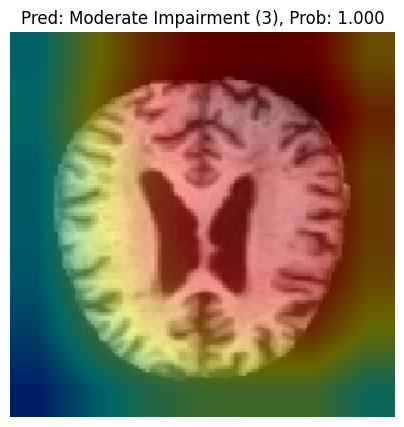

In [ ]:
img_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/28 (25).jpg"

class_labels = ['No Impairment', 'Very Mild Impairment', 'Mild Impairment', 'Moderate Impairment']

display_scorecam(model, img_path, last_conv_layer_name="conv5_block3_out", class_labels=class_labels)


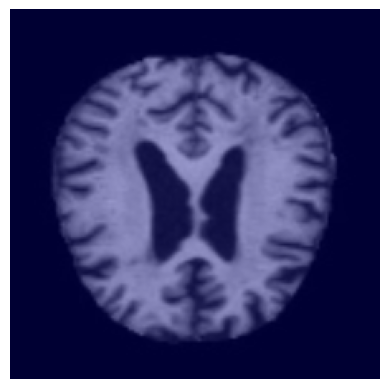

In [ ]:
img_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/28 (25).jpg"

# Preprocess single image
from tensorflow.keras.applications.resnet50 import preprocess_input

img_array = preprocess_input(img_array)

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

# Run Grad-CAM++
last_conv_layer_name = "conv5_block3_out"
heatmap = gradcam_plus_plus(model, img_array, last_conv_layer_name)

# Overlay & display
overlayed = overlay_heatmap(heatmap, img_path)
plt.imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


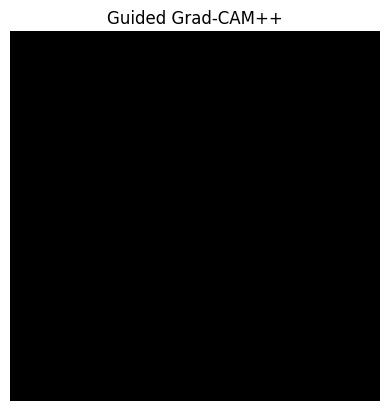

In [ ]:
# Run Grad-CAM++ as before
heatmap = gradcam_plus_plus(model, img_array, last_conv_layer_name, class_index=3)

# Guided backprop
with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    tape.watch(inputs)
    preds = guided_model(inputs)
    loss = preds[:, class_index]

guided_grads = tape.gradient(loss, inputs)[0].numpy()

# Combine guided backprop with Grad-CAM++ heatmap
guided_gradcam = np.maximum(guided_grads, 0)
guided_gradcam = guided_gradcam / (guided_gradcam.max() + 1e-10)
guided_gradcam = guided_gradcam * np.expand_dims(cv2.resize(heatmap, (224, 224)), axis=-1)

# Visualize
plt.imshow(np.squeeze(guided_gradcam))
plt.axis('off')
plt.title("Guided Grad-CAM++")
plt.show()


In [ ]:
# Predict with ResNet50 model
resnet_preds = model.predict(test_generator, verbose=1)
resnet_y_pred = np.argmax(resnet_preds, axis=1)  # convert softmax probabilities to class indices

In [ ]:
_ = model.predict(img_array)  # runs one forward pass to define outputs


In [ ]:
for layer in model.layers[0].layers[-10:]:
    print(layer.name, layer.output)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
g_dict = test_generator.class_indices
classes = list(g_dict.keys())
# For ResNet50
cm_resnet = confusion_matrix(test_generator.classes, resnet_y_pred)
print(classification_report(test_generator.classes, resnet_y_pred, target_names=classes))

In [ ]:
# Image settings
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Number of classes
class_count = len(list(train_generator.class_indices.keys()))  # e.g., 4

# Load VGG16 base model
base_model = tf.keras.applications.VGG16(
    include_top=False,         # remove default classifier
    weights='imagenet',        # pretrained weights
    input_shape=img_shape,
    pooling='max'              # global max pooling
)

# Build full model
model = Sequential([
    base_model,
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(class_count, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(), metrics = ['accuracy'])

early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True, verbose = 1)

history = model.fit(train_generator,
    validation_data=test_generator,
    epochs=30,
    steps_per_epoch = 50,
    callbacks = [early_stopping_callbacks])

In [ ]:
# Predict with VGG16 model
vgg_preds = model.predict(test_generator, verbose=1)
vgg_y_pred = np.argmax(vgg_preds, axis=1)        # convert softmax probabilities to class indices

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# For VGG16
cm_vgg = confusion_matrix(test_generator.classes, vgg_y_pred)
print(classification_report(test_generator.classes, vgg_y_pred, target_names=classes))
